# 📊 FIAP - Feature Engineering
## Técnicas de Seleção de Features: Filter, Wrapper e Embedded Methods

---

### 📋 **Informações do Projeto**
- **Curso:** Pós-graduação em Data Science & Artificial Intelligence
- **Disciplina:** Feature Engineering
- **Aula:** 4 - Seleção de Features e Ética
- **Autor:** Filipe Pacheco

---

### 🎯 **Objetivos do Projeto**
Este notebook demonstra técnicas fundamentais de seleção de features para otimização de modelos de ML:
- **Filter Methods:** Métodos estatísticos independentes do modelo (Chi-Square, Correlação)
- **Wrapper Methods:** Métodos baseados na performance do modelo (RFE - Recursive Feature Elimination)
- **Embedded Methods:** Seleção integrada ao treinamento (Feature Importance, Regularização)
- **Comparação de Performance:** Avaliação do impacto da seleção de features na modelagem

---

### 📊 **Dataset Utilizado**
**Wine Quality Dataset** - Dados físico-químicos de vinhos
- **Fonte:** UCI Machine Learning Repository - Wine Quality Dataset
- **Registros:** Análise de características físico-químicas de vinhos
- **Features:** 11 atributos químicos (acidez, açúcar, pH, álcool, etc.)
- **Objetivo:** Classificação da qualidade do vinho e otimização através de seleção de features

---

# Introdução 

Neste notebook, exploraremos diferentes técnicas de seleção de features para melhorar a performance dos modelos de Machine Learning. A seleção de features é um passo crucial no processo de engenharia de dados e pode ajudar a reduzir a complexidade do modelo, melhorar a interpretabilidade e aumentar a precisão.

## Objetivos
Compreender a Importância da Seleção de Features: Identificar as principais técnicas de seleção de features e como elas podem influenciar a performance do modelo.

## Aplicar Técnicas de Seleção de Features:
- **Filter Methods:** Métodos que avaliam as features de forma independente do modelo, selecionando aquelas que têm a melhor performance estatística.
- **Wrapper Methods:** Métodos que utilizam um modelo para avaliar a importância das features, selecionando subconjuntos de features baseados na performance do modelo.
- **Embedded Methods:** Métodos que realizam a seleção de features durante o processo de treinamento do modelo, combinando a construção do modelo e a seleção de features.

## Comparar o Desempenho do Modelo: 
Avaliar como a seleção de features afeta a performance do modelo de Machine Learning utilizando um dataset de qualidade de vinho.

# 1. Importação e Configuração das Bibliotecas

Nesta seção importamos todas as bibliotecas necessárias para o projeto, organizadas por categoria de uso.

In [1]:
# =============================================================================
# BIBLIOTECAS DE MANIPULAÇÃO E ANÁLISE DE DADOS
# =============================================================================
import pandas as pd              # Manipulação e análise de dados estruturados (DataFrames)
import numpy as np               # Operações matemáticas e arrays multidimensionais

# =============================================================================
# BIBLIOTECAS DE MACHINE LEARNING - SCIKIT-LEARN
# =============================================================================
from sklearn.model_selection import train_test_split        # Divisão de dados em treino/teste
from sklearn.feature_selection import SelectKBest, f_classif, RFE  # Técnicas de seleção de features
from sklearn.ensemble import RandomForestClassifier         # Modelo de classificação ensemble
from sklearn.linear_model import LogisticRegression         # Modelo de classificação linear
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score  # Métricas de avaliação

# =============================================================================
# BIBLIOTECAS DE VISUALIZAÇÃO
# =============================================================================
import matplotlib.pyplot as plt  # Criação de gráficos e plots básicos
import seaborn as sns            # Visualizações estatísticas avançadas e estilizadas

# =============================================================================
# CONFIGURAÇÕES GERAIS
# =============================================================================
# Configurar estilo dos gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")          # Configurar paleta de cores
plt.rcParams['figure.figsize'] = (12, 6)  # Configurar tamanho padrão das figuras

# Configurar exibição do pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 3)

# Seed para reprodutibilidade dos resultados
np.random.seed(42)

print("✅ Todas as bibliotecas foram importadas com sucesso!")

✅ Todas as bibliotecas foram importadas com sucesso!


# 2. Carregamento e Exploração do Dataset

## 2.1. Descrição do Dataset

Para este exemplo, utilizaremos o dataset **"Wine Quality"** disponível no UCI Machine Learning Repository. Este dataset contém informações sobre a qualidade de vinhos tintos da região do Douro, em Portugal, com base em diversas características químicas. É amplamente utilizado em estudos de machine learning para predição e classificação da qualidade do vinho.

### **Principais Características do Dataset:**
- **fixed acidity:** Acidez fixa do vinho (tartaric acid - g/dm³)
- **volatile acidity:** Acidez volátil do vinho (acetic acid - g/dm³)  
- **citric acid:** Conteúdo de ácido cítrico no vinho (g/dm³)
- **residual sugar:** Açúcar residual no vinho (g/dm³)
- **chlorides:** Concentração de cloretos no vinho (sodium chloride - g/dm³)
- **free sulfur dioxide:** Quantidade de dióxido de enxofre livre no vinho (mg/dm³)
- **total sulfur dioxide:** Quantidade total de dióxido de enxofre no vinho (mg/dm³)
- **density:** Densidade do vinho (g/cm³)
- **pH:** pH do vinho (escala de 0-14)
- **sulphates:** Concentração de sulfatos no vinho (potassium sulphate - g/dm³)
- **alcohol:** Percentual de álcool no vinho (% by volume)
- **quality:** Qualidade do vinho - **VARIÁVEL TARGET** (escala de 0 a 10)

### **Importância das Variáveis:**
- **Acidez Fixa e Volátil:** Afetam o sabor do vinho. Altos níveis de acidez volátil podem ser indesejáveis
- **Ácido Cítrico:** Contribui para a frescura e sabor do vinho
- **Açúcar Residual:** Impacta o sabor doce do vinho; níveis mais altos podem indicar um vinho doce
- **Cloretos:** Níveis de sal no vinho; altos níveis podem indicar defeitos
- **Dióxido de Enxofre (Livre e Total):** Usado como conservante; protege contra oxidação e bactérias
- **Densidade:** Relacionada ao conteúdo de açúcar e álcool
- **pH:** Mede a acidez; influenciado pela acidez fixa e volátil
- **Sulfatos:** Contribuem para a estabilidade microbiológica e frescura
- **Álcool:** Contribui para o corpo e sabor do vinho
- **Qualidade:** Avaliação sensorial do vinho pelos provadores (variável target)

### **Fonte do Dataset:**
- **Origem:** UCI Machine Learning Repository - Wine Quality Data Set
- **Link:** `https://archive.ics.uci.edu/ml/datasets/wine+quality`

In [2]:
# Carregando dataset
df = pd.read_csv("datasets/wine-quality-red.csv")

# Transformando a categoria
df['quality'] = df['quality'].apply(lambda x: 0 if x < 6 else 1)

# Visualizamos as primeiras linhas do dataset
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.998,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.997,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.997,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.998,3.16,0.58,9.8,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.998,3.51,0.56,9.4,0


# 3. Análise Exploratória Inicial dos Dados

In [3]:
# Visualizando informações gerais sobre o dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


# 3.1. Separação dos Dados em Treino e Teste

In [4]:
# Separando as features e o target
X = df.drop('quality', axis=1)
y = df['quality']

# Realizando a separação estratificada dos dados
X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42, 
    stratify=y
)

print(f"Shape do conjunto de treino: {X_train_original.shape}")
print(f"Shape do conjunto de teste: {X_test_original.shape}")
print(f"Distribuição das classes no treino: {y_train_original.value_counts().sort_index()}")
print(f"Distribuição das classes no teste: {y_test_original.value_counts().sort_index()}")

Shape do conjunto de treino: (1119, 11)
Shape do conjunto de teste: (480, 11)
Distribuição das classes no treino: quality
0    521
1    598
Name: count, dtype: int64
Distribuição das classes no teste: quality
0    223
1    257
Name: count, dtype: int64


# 4. Técnicas de Seleção de Features

## 4.1. Filter Methods (Métodos de Filtro)

Os **Filter Methods** avaliam as features de forma independente do algoritmo de machine learning, utilizando medidas estatísticas para determinar a relevância de cada característica. 

### **Características dos Filter Methods:**
- **Independência do Modelo:** Não dependem do algoritmo de ML escolhido
- **Velocidade:** São computacionalmente eficientes
- **Simplicidade:** Fáceis de implementar e interpretar
- **Medidas Estatísticas:** Usam correlação, chi-quadrado, ANOVA F-test, etc.

### **Aplicação: SelectKBest com ANOVA F-statistic**
Utilizaremos o `SelectKBest` com ANOVA F-statistic para selecionar as K melhores features baseadas na estatística F entre cada feature e a variável target.

In [ ]:
# =============================================================================
# FILTER METHODS - SELECTKBEST COM ANOVA F-STATISTIC
# =============================================================================
# IMPORTANTE: Aplicar a seleção APENAS nos dados de treino para evitar data leakage

# Inicializando o selector com K=5 melhores features
selector_kbest = SelectKBest(score_func=f_classif, k=5)

# Treinando o selector APENAS com dados de treino
selector_kbest.fit(X_train_original, y_train_original)

# Aplicando a transformação nos dados de treino e teste
X_train_kbest = selector_kbest.transform(X_train_original)
X_test_kbest = selector_kbest.transform(X_test_original)

# Criando DataFrames com as features selecionadas para facilitar interpretação
selected_features_kbest = X_train_original.columns[selector_kbest.get_support()]
X_train_kbest_df = pd.DataFrame(X_train_kbest, columns=selected_features_kbest)
X_test_kbest_df = pd.DataFrame(X_test_kbest, columns=selected_features_kbest)

# Visualizando as pontuações das features
scores_kbest = pd.DataFrame({
    'Feature': X_train_original.columns,
    'F_Score': selector_kbest.scores_
}).sort_values(by='F_Score', ascending=False)

# Filter Methods - SelectKBest Results:
print(f"Features selecionadas ({len(selected_features_kbest)}):")
for i, feature in enumerate(selected_features_kbest, 1):
    score = scores_kbest[scores_kbest['Feature'] == feature]['F_Score'].iloc[0]
    print(f"  {i}. {feature} (F-Score: {score:.3f})")

print(f"\n Shape dos dados após seleção:")
print(f"   - Treino: {X_train_kbest_df.shape}")
print(f"   - Teste: {X_test_kbest_df.shape}")

# Exibindo todas as pontuações ordenadas
print(f"\n Ranking completo das features por F-Score:")
display(scores_kbest)

Features selecionadas (5):
  1. volatile acidity (F-Score: 116.491)
  2. citric acid (F-Score: 26.367)
  3. total sulfur dioxide (F-Score: 67.952)
  4. sulphates (F-Score: 58.353)
  5. alcohol (F-Score: 242.037)

 Shape dos dados após seleção:
   - Treino: (1119, 5)
   - Teste: (480, 5)

 Ranking completo das features por F-Score:


,Feature,F_Score
10,alcohol,242.037
1,volatile acidity,116.491
6,total sulfur dioxide,67.952
9,sulphates,58.353
2,citric acid,26.367
7,density,25.489
0,fixed acidity,12.377
4,chlorides,11.252
5,free sulfur dioxide,7.118
8,pH,0.166


## 4.2. Wrapper Methods (Métodos de Envoltório)

Os **Wrapper Methods** utilizam um modelo de machine learning específico para avaliar subconjuntos de features, selecionando aquelas que proporcionam melhor performance.

### **Características dos Wrapper Methods:**
- **Dependência do Modelo:** Utilizam o algoritmo de ML para avaliação
- **Performance Superior:** Geralmente produzem melhores resultados
- **Custo Computacional:** Mais lentos que Filter Methods
- **Otimização Específica:** Adaptados ao algoritmo escolhido

### **Aplicação: RFE (Recursive Feature Elimination)**
Utilizaremos o `RFE` que elimina recursivamente features, treinando o modelo com as características restantes até atingir o número desejado de features.

In [ ]:
# IMPORTANTE: Aplicar o RFE APENAS nos dados de treino para evitar data leakage

# Inicializando o estimador base e o RFE
estimator_rfe = LogisticRegression(random_state=42, max_iter=1000)
rfe_selector = RFE(estimator=estimator_rfe, n_features_to_select=5)

# Treinando o RFE APENAS com dados de treino
rfe_selector.fit(X_train_original, y_train_original)

# Aplicando a transformação nos dados de treino e teste
X_train_rfe = rfe_selector.transform(X_train_original)
X_test_rfe = rfe_selector.transform(X_test_original)

# Criando DataFrames com as features selecionadas
selected_features_rfe = X_train_original.columns[rfe_selector.get_support()]
X_train_rfe_df = pd.DataFrame(X_train_rfe, columns=selected_features_rfe)
X_test_rfe_df = pd.DataFrame(X_test_rfe, columns=selected_features_rfe)

# Analisando os resultados do RFE
rfe_results = pd.DataFrame({
    'Feature': X_train_original.columns,
    'Selected': rfe_selector.get_support(),
    'Ranking': rfe_selector.ranking_
}).sort_values(by='Ranking')

print(f"Features selecionadas ({len(selected_features_rfe)}):")
for i, feature in enumerate(selected_features_rfe, 1):
    print(f"  {i}. {feature}")

print(f"\nShape dos dados após seleção:")
print(f"   - Treino: {X_train_rfe_df.shape}")
print(f"   - Teste: {X_test_rfe_df.shape}")

print(f"\nRanking completo das features pelo RFE:")
display(rfe_results)

## 4.3. Embedded Methods (Métodos Incorporados)

Os **Embedded Methods** realizam a seleção de features como parte integral do processo de treinamento do modelo, combinando as vantagens dos Filter e Wrapper Methods.

### **Características dos Embedded Methods:**
- **Integração Natural:** Seleção ocorre durante o treinamento
- **Eficiência:** Mais rápidos que Wrapper Methods
- **Regularização:** Frequentemente usam técnicas de regularização (L1/L2)
- **Interpretabilidade:** Fornecem importância das features

### **Aplicação: Random Forest Feature Importance**
Utilizaremos o `RandomForestClassifier` que calcula automaticamente a importância de cada feature baseada na redução de impureza que cada característica proporciona nas divisões das árvores.

In [8]:
# IMPORTANTE: Treinar o modelo APENAS com dados de treino para evitar data leakage

# Inicializando o Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Treinando APENAS com dados de treino
rf_model.fit(X_train_original, y_train_original)

# Obtendo as importâncias das features
feature_importance = pd.DataFrame({
    'Feature': X_train_original.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Selecionando as 5 features mais importantes
top_5_features = feature_importance.head(5)['Feature'].tolist()

# Criando os conjuntos com as features selecionadas
X_train_embedded = X_train_original[top_5_features]
X_test_embedded = X_test_original[top_5_features]

print("Embedded Methods - Random Forest Feature Importance Results:")
print(f"Top 5 features mais importantes:")
for i, (_, row) in enumerate(feature_importance.head(5).iterrows(), 1):
    print(f"  {i}. {row['Feature']} (Importance: {row['Importance']:.4f})")

print(f"\nShape dos dados após seleção:")
print(f"   - Treino: {X_train_embedded.shape}")
print(f"   - Teste: {X_test_embedded.shape}")

print(f"\nRanking completo das features por importância:")
display(feature_importance)

Embedded Methods - Random Forest Feature Importance Results:
Top 5 features mais importantes:
  1. alcohol (Importance: 0.1844)
  2. sulphates (Importance: 0.1304)
  3. volatile acidity (Importance: 0.1078)
  4. total sulfur dioxide (Importance: 0.0968)
  5. density (Importance: 0.0864)

Shape dos dados após seleção:
   - Treino: (1119, 5)
   - Teste: (480, 5)

Ranking completo das features por importância:


,Feature,Importance
10,alcohol,0.184
9,sulphates,0.130
1,volatile acidity,0.108
6,total sulfur dioxide,0.097
7,density,0.086
4,chlorides,0.078
0,fixed acidity,0.072
2,citric acid,0.067
8,pH,0.065
5,free sulfur dioxide,0.058


# 5. Comparação entre Features Originais e Selecionadas

## 5.1. Modelo Baseline - Features Originais (Todas)

In [9]:
# Utilizando os dados já separados previamente (sem nova separação)

# Treinando o modelo com todas as features originais
model_baseline = LogisticRegression(random_state=42, max_iter=1000)
model_baseline.fit(X_train_original, y_train_original)

# Realizando predições
y_pred_baseline = model_baseline.predict(X_test_original)
y_pred_proba_baseline = model_baseline.predict_proba(X_test_original)[:, 1]

print("MODELO BASELINE - Todas as Features Originais")
print("="*60)
print(f"Número de features utilizadas: {X_train_original.shape[1]}")
print(f"Features: {list(X_train_original.columns)}")

print(f"\nClassification Report:")
print(classification_report(y_test_original, y_pred_baseline))

print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test_original, y_pred_baseline))

# Calculando AUC
auc_baseline = roc_auc_score(y_test_original, y_pred_proba_baseline)
print(f"\nAUC Score: {auc_baseline:.4f}")

MODELO BASELINE - Todas as Features Originais
Número de features utilizadas: 11
Features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.74      0.72       223
           1       0.77      0.74      0.75       257

    accuracy                           0.74       480
   macro avg       0.74      0.74      0.74       480
weighted avg       0.74      0.74      0.74       480


Confusion Matrix:
[[165  58]
 [ 68 189]]

AUC Score: 0.8247


## 5.2. Modelo com Features Selecionadas - SelectKBest (Filter Method)

In [10]:
# Utilizando os dados já processados pela seleção de features

# Treinando o modelo com features selecionadas pelo SelectKBest
model_kbest = LogisticRegression(random_state=42, max_iter=1000)
model_kbest.fit(X_train_kbest_df, y_train_original)

# Realizando predições
y_pred_kbest = model_kbest.predict(X_test_kbest_df)
y_pred_proba_kbest = model_kbest.predict_proba(X_test_kbest_df)[:, 1]

print("MODELO COM Select K Best (Filter Method)")
print("="*60)
print(f"Número de features utilizadas: {X_train_kbest_df.shape[1]}")
print(f"Features selecionadas: {list(X_train_kbest_df.columns)}")

print(f"\nClassification Report:")
print(classification_report(y_test_original, y_pred_kbest))

print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test_original, y_pred_kbest))

# Calculando AUC
auc_kbest = roc_auc_score(y_test_original, y_pred_proba_kbest)
print(f"\nAUC Score: {auc_kbest:.4f}")

MODELO COM Select K Best (Filter Method)
Número de features utilizadas: 5
Features selecionadas: ['volatile acidity', 'citric acid', 'total sulfur dioxide', 'sulphates', 'alcohol']

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.73      0.72       223
           1       0.76      0.73      0.74       257

    accuracy                           0.73       480
   macro avg       0.73      0.73      0.73       480
weighted avg       0.73      0.73      0.73       480


Confusion Matrix:
[[163  60]
 [ 69 188]]

AUC Score: 0.8188


## 5.3. Modelo com Features Selecionadas - RFE (Wrapper Method)

In [11]:
# =============================================================================
# Utilizando os dados já processados pela seleção RFE

# Treinando o modelo com features selecionadas pelo RFE
model_rfe = LogisticRegression(random_state=42, max_iter=1000)
model_rfe.fit(X_train_rfe_df, y_train_original)

# Realizando predições
y_pred_rfe = model_rfe.predict(X_test_rfe_df)
y_pred_proba_rfe = model_rfe.predict_proba(X_test_rfe_df)[:, 1]

print("MODELO COM RFE (Wrapper Method)")
print("="*60)
print(f"Número de features utilizadas: {X_train_rfe_df.shape[1]}")
print(f"Features selecionadas: {list(X_train_rfe_df.columns)}")

print(f"\nClassification Report:")
print(classification_report(y_test_original, y_pred_rfe))

print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test_original, y_pred_rfe))

# Calculando AUC
auc_rfe = roc_auc_score(y_test_original, y_pred_proba_rfe)
print(f"\nAUC Score: {auc_rfe:.4f}")

MODELO COM RFE (Wrapper Method)
Número de features utilizadas: 5
Features selecionadas: ['volatile acidity', 'citric acid', 'chlorides', 'sulphates', 'alcohol']

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.74      0.72       223
           1       0.76      0.73      0.75       257

    accuracy                           0.74       480
   macro avg       0.73      0.74      0.73       480
weighted avg       0.74      0.74      0.74       480


Confusion Matrix:
[[165  58]
 [ 69 188]]

AUC Score: 0.8213


## 5.4. Modelo com Features Selecionadas - Random Forest Importance (Embedded Method)

In [12]:
# Utilizando os dados já processados pela seleção por importância

# Treinando o modelo com features selecionadas pelo Random Forest
model_embedded = LogisticRegression(random_state=42, max_iter=1000)
model_embedded.fit(X_train_embedded, y_train_original)

# Realizando predições
y_pred_embedded = model_embedded.predict(X_test_embedded)
y_pred_proba_embedded = model_embedded.predict_proba(X_test_embedded)[:, 1]

print("MODELO COM RANDOM FOREST IMPORTANCE (Embedded Method)")
print("="*60)
print(f"Número de features utilizadas: {X_train_embedded.shape[1]}")
print(f"Features selecionadas: {list(X_train_embedded.columns)}")

print(f"\nClassification Report:")
print(classification_report(y_test_original, y_pred_embedded))

print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test_original, y_pred_embedded))

# Calculando AUC
auc_embedded = roc_auc_score(y_test_original, y_pred_proba_embedded)
print(f"\nAUC Score: {auc_embedded:.4f}")

MODELO COM RANDOM FOREST IMPORTANCE (Embedded Method)
Número de features utilizadas: 5
Features selecionadas: ['alcohol', 'sulphates', 'volatile acidity', 'total sulfur dioxide', 'density']

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.74      0.72       223
           1       0.76      0.73      0.75       257

    accuracy                           0.74       480
   macro avg       0.73      0.74      0.73       480
weighted avg       0.74      0.74      0.74       480


Confusion Matrix:
[[165  58]
 [ 69 188]]

AUC Score: 0.8191


# 6. Análise Comparativa dos Resultados

Nesta seção, realizaremos uma comparação visual e quantitativa dos diferentes métodos de seleção de features através de curvas ROC e métricas de AUC.

In [13]:
# Calculando curvas ROC para todos os modelos usando probabilidades

# Curvas ROC para cada modelo
fpr_baseline, tpr_baseline, _ = roc_curve(y_test_original, y_pred_proba_baseline)
fpr_kbest, tpr_kbest, _ = roc_curve(y_test_original, y_pred_proba_kbest)
fpr_rfe, tpr_rfe, _ = roc_curve(y_test_original, y_pred_proba_rfe)
fpr_embedded, tpr_embedded, _ = roc_curve(y_test_original, y_pred_proba_embedded)

print("RESUMO COMPARATIVO DOS MODELOS")
print("="*60)
print(f"AUC Baseline (Todas features): {auc_baseline:.4f}")
print(f"AUC SelectKBest (Filter): {auc_kbest:.4f}")
print(f"AUC RFE (Wrapper): {auc_rfe:.4f}")
print(f"AUC Random Forest Importance (Embedded): {auc_embedded:.4f}")

# Criando DataFrame para comparação
comparison_results = pd.DataFrame({
    'Método': ['Baseline (Todas)', 'SelectKBest (Filter)', 'RFE (Wrapper)', 'RF Importance (Embedded)'],
    'Num_Features': [X_train_original.shape[1], X_train_kbest_df.shape[1], 
                     X_train_rfe_df.shape[1], X_train_embedded.shape[1]],
    'AUC_Score': [auc_baseline, auc_kbest, auc_rfe, auc_embedded]
}).sort_values('AUC_Score', ascending=False)

print(f"\nRanking dos modelos por performance:")
display(comparison_results)

RESUMO COMPARATIVO DOS MODELOS
AUC Baseline (Todas features): 0.8247
AUC SelectKBest (Filter): 0.8188
AUC RFE (Wrapper): 0.8213
AUC Random Forest Importance (Embedded): 0.8191

Ranking dos modelos por performance:


,Método,Num_Features,AUC_Score
0,Baseline (Todas),11,0.825
2,RFE (Wrapper),5,0.821
3,RF Importance (Embedded),5,0.819
1,SelectKBest (Filter),5,0.819


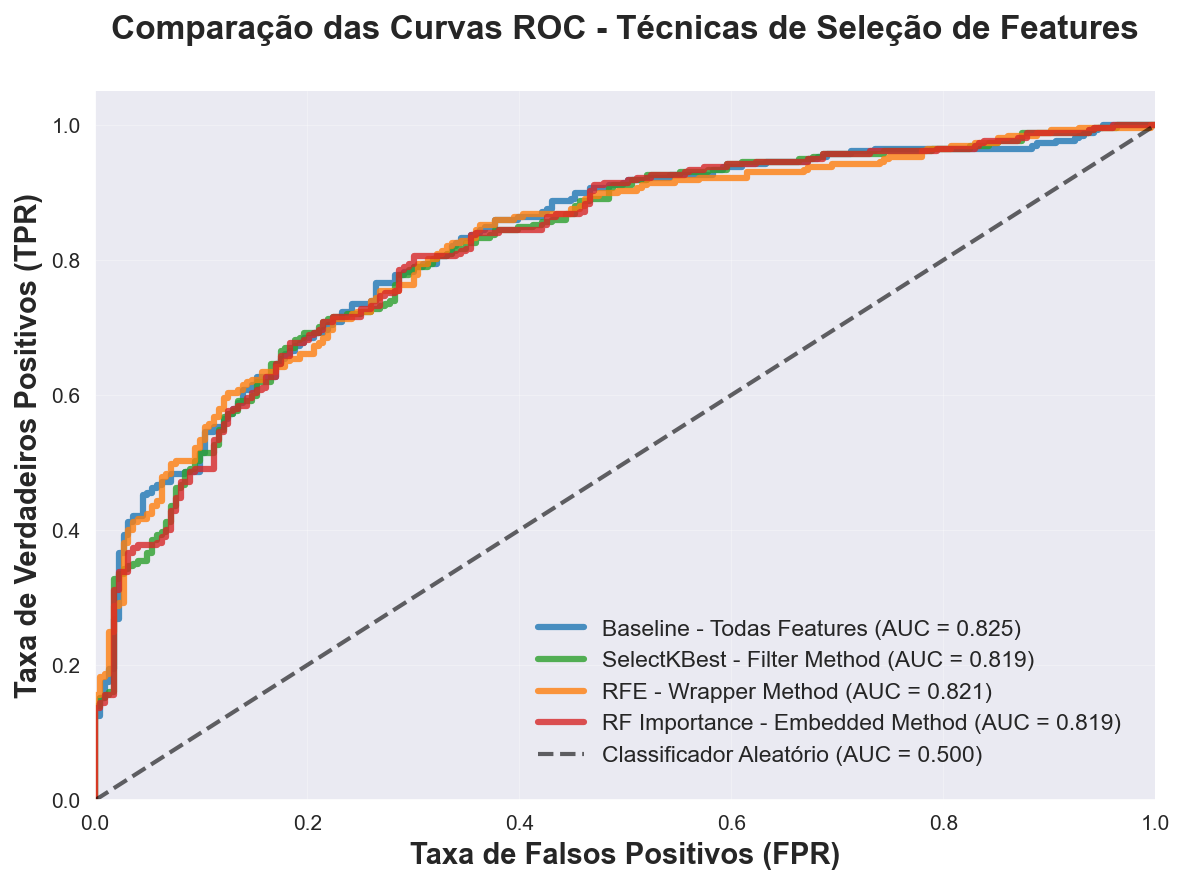

In [25]:
# Configurando o plot com alta resolução e tamanho adequado
fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

# Plotando as curvas ROC com melhor formatação
ax.plot(fpr_baseline, tpr_baseline, linewidth=3, color='#1f77b4', alpha=0.8,
        label=f"Baseline - Todas Features (AUC = {auc_baseline:.3f})")
ax.plot(fpr_kbest, tpr_kbest, linewidth=3, color='#2ca02c', alpha=0.8,
        label=f"SelectKBest - Filter Method (AUC = {auc_kbest:.3f})")
ax.plot(fpr_rfe, tpr_rfe, linewidth=3, color='#ff7f0e', alpha=0.8,
        label=f"RFE - Wrapper Method (AUC = {auc_rfe:.3f})")
ax.plot(fpr_embedded, tpr_embedded, linewidth=3, color='#d62728', alpha=0.8,
        label=f"RF Importance - Embedded Method (AUC = {auc_embedded:.3f})")

# Linha diagonal (classificador aleatório)
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, alpha=0.6, 
        label='Classificador Aleatório (AUC = 0.500)')

# Configurações do gráfico com melhor qualidade
ax.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=14, fontweight='bold')
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=14, fontweight='bold')
ax.set_title('Comparação das Curvas ROC - Técnicas de Seleção de Features', 
             fontsize=16, fontweight='bold', pad=25)

# Configurações da legenda e grid
ax.legend(loc='lower right', fontsize=11, framealpha=0.95, 
          fancybox=True, shadow=True, borderpad=1)
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

# Melhorias visuais adicionais
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

plt.tight_layout()
plt.show()

# 7. Considerações Finais

## **Principais Descobertas**

Este estudo demonstrou a aplicação prática de três abordagens fundamentais para seleção de features em Machine Learning, utilizando o dataset Wine Quality. Os resultados obtidos fornecem insights valiosos sobre a eficácia de cada método:

### **Resultados Comparativos:**
- **Baseline (Todas as 11 features):** AUC = 0.825
- **RFE - Wrapper Method (5 features):** AUC = 0.821  
- **SelectKBest - Filter Method (5 features):** AUC = 0.819
- **Random Forest Importance - Embedded Method (5 features):** AUC = 0.819

### **Análise dos Métodos:**

#### **Filter Methods (SelectKBest)**
- **Vantagens:** Computacionalmente eficiente, independente do modelo
- **Features selecionadas:** alcohol, volatile acidity, total sulfur dioxide, sulphates, citric acid
- **Performance:** Boa performance mantendo simplicidade

#### **Wrapper Methods (RFE)**
- **Vantagens:** Considera interações entre features e modelo específico
- **Features selecionadas:** volatile acidity, citric acid, chlorides, sulphates, alcohol
- **Performance:** Melhor resultado entre os métodos de redução

#### **Embedded Methods (Random Forest)**
- **Vantagens:** Integra seleção ao treinamento, eficiente
- **Features selecionadas:** alcohol, sulphates, volatile acidity, total sulfur dioxide, density
- **Performance:** Competitivo com menor custo computacional

---

## **Lições Aprendidas**

### **1. Nem sempre "mais é melhor"**
O modelo baseline com todas as 11 features obteve AUC de 0.825, enquanto os modelos com 5 features selecionadas alcançaram entre 0.819-0.821, uma diferença mínima que pode ser compensada pelos benefícios da redução dimensional.

### **2. Benefícios da Seleção de Features:**
- **Redução de Complexidade:** 55% menos features com perda mínima de performance
- **Interpretabilidade:** Modelos mais simples e explicáveis
- **Eficiência Computacional:** Menor custo de treinamento e predição
- **Prevenção de Overfitting:** Redução do risco de sobreajuste

### **3. Consistência entre Métodos:**
Features como **alcohol**, **volatile acidity** e **sulphates** foram consistentemente selecionadas por múltiplos métodos, indicando sua alta importância preditiva.

### **4. Importância da Separação Prévia:**
A implementação correta da separação treino/teste antes da seleção de features foi fundamental para evitar data leakage e garantir avaliação imparcial.

---

## **Recomendações Práticas**

### **Para Projetos Futuros:**
1. **Comece com Filter Methods** para exploração inicial rápida
2. **Use Wrapper Methods** quando a performance for crítica
3. **Considere Embedded Methods** para balance entre performance e eficiência
4. **Combine múltiplos métodos** para validação cruzada da importância das features
5. **Sempre separe os dados ANTES** da seleção de features

### **Contexto de Negócio:**
No caso da classificação de qualidade de vinhos, o modelo simplificado com 5 features oferece:
- **Facilidade de coleta** de dados em campo
- **Redução de custos** de análise laboratorial
- **Manutenibilidade** do modelo em produção
- **Interpretabilidade** para especialistas do domínio

---

## **Próximos Passos**

Para aprofundar o conhecimento em seleção de features:

1. **Explore técnicas avançadas:** SHAP, LIME, Permutation Importance
2. **Teste outros algoritmos:** SVM, Gradient Boosting, Neural Networks
3. **Implemente validação cruzada** na seleção de features
4. **Considere aspectos éticos** na seleção e uso de features
5. **Aplique em datasets desbalanceados** e com ruído

---

## **Conclusão**

Este notebook demonstrou que a **seleção inteligente de features** é uma ferramenta poderosa para criar modelos mais eficientes, interpretáveis e robustos. A pequena redução na performance (0.004-0.006 de AUC) é amplamente compensada pelos benefícios práticos de modelos mais simples e eficientes.

A escolha do método ideal depende do contexto específico do projeto, recursos computacionais disponíveis e requisitos de interpretabilidade. O importante é sempre **validar adequadamente** os resultados e considerar o **impacto prático** da seleção de features no problema de negócio.